In [1]:
%matplotlib qt

In [2]:
import pdb
import pandas as pd
import biosignalsnotebooks as bsnb
import CalculateSMR
import matlab
import matplotlib.pyplot as plt
import numpy as np
import mne
from analyzer import Analyzer
from data_loader import DataLoader
from preprocessing import Preprocessing
import philistine
# biosignalsnotebooks python package
import biosignalsnotebooks as bsnb
import matplotlib.pyplot as plt

# Numpy package is dedicated to simplify the work (operations between) with arrays/lists
from numpy import cumsum, concatenate, zeros, linspace, average, power, absolute, mean, std, max, array, diff, where

# Scientific packages
from scipy.signal import butter, lfilter
from scipy.stats import linregress

# Base packages used in OpenSignals Tools Notebooks for ploting data
from bokeh.plotting import output_file, show
from bokeh.io import output_notebook
from bokeh.layouts import gridplot
output_notebook(hide_banner=True)
import pandas as pd

choose session

import data

In [3]:
def create_raw(data, ch_name):
    info = mne.create_info(sfreq = data_loader.fs, ch_names = ch_name, ch_types='emg')
    raw_array = mne.io.RawArray(data, info)# convert uV to V
    return raw_array

In [4]:
def plot_data(data, ch_name, duration):
    raw_data = create_raw(np.expand_dims(data, axis=0), [ch_name])
    raw_data.set_annotations(data_loader.annot_from_events)
    raw_data.plot(duration=duration);    

In [5]:
# [Application of TKEO Operator]
def tkeo(data):
    tkeo = []
    for i in range(0, len(data)):
        if i == 0 or i == len(data) - 1:
            tkeo.append(data[i])
        else:
            tkeo.append(power(data[i], 2) - (data[i + 1] * data[i - 1]))
    return np.asarray(tkeo)

In [6]:
# [Second Smoothing Phase]
def smooth(data, smoothing_level):
    smooth_signal = []
    for i in range(0, len(data)):
        if smoothing_level < i < len(data) - smoothing_level:
            smooth_signal.append(mean(data[i - smoothing_level:i + smoothing_level]))
        else:
            smooth_signal.append(0)
    return np.asarray(smooth_signal)

In [7]:
# Regression function.
def normReg(thresholdLevel, avg_pre_pro_signal, std_pre_pro_signal, smooth_signal):
    threshold_0_perc_level = (- avg_pre_pro_signal) / float(std_pre_pro_signal)
    threshold_100_perc_level = (max(smooth_signal) - avg_pre_pro_signal) / float(std_pre_pro_signal)
    m, b = linregress([0, 100], [threshold_0_perc_level, threshold_100_perc_level])[:2]
    return m * thresholdLevel + b 

In [8]:
# Generation of a square wave reflecting the activation and inactivation periods.
def binary(time, smooth_signal, threshold):
    binary_signal = []
    for i in range(0, len(time)):
        if smooth_signal[i] >= threshold:
            binary_signal.append(1)
        else:
            binary_signal.append(0)
    return np.asarray(binary_signal)

In [9]:
def mask(data_loader, task_type):
    event_array = np.c_[data_loader.annot_from_events.onset, data_loader.annot_from_events.description]
    event_onsets_idx = np.where(event_array[:, 1]==task_type)[0]
    event_onsets = event_array[event_onsets_idx, :][:, 0]
    event_onsets = event_onsets.astype(float)
    event_periods = list(zip(event_onsets, event_onsets+ 5))
    mask = np.zeros_like(data_loader.raw_array.copy().times)
    for (start, stop) in event_periods:
        mask[int(start*data_loader.fs): int(stop*data_loader.fs)] = 1
    return mask

In [10]:
def visual_cue(data_loader, task_type, bad_epoch):
    event_array = np.c_[data_loader.annot_from_events.onset, data_loader.annot_from_events.description]
    event_onsets_idx = np.where(event_array[:, 1]==task_type)[0]
    event_onsets = event_array[event_onsets_idx, :][:, 0]
    event_onsets = event_onsets.astype(float)
    if bad_epoch != -1:
        event_onsets = np.delete(event_onsets, bad_epoch-1)
    return event_onsets

In [11]:
def delete_redundent_onsets(EMG_onsets):
    index_delete = []
    for i in range(len(EMG_onsets)-1):
        if EMG_onsets[i+1] - EMG_onsets[i] <=5:
            index_delete.append(i+1)
    EMG_onsets = np.delete(EMG_onsets,index_delete)
    return EMG_onsets

In [12]:
def closest(lst, K): 
      
    return lst[min(range(len(lst)), key = lambda i: abs(lst[i]-K))] 

## import data 

In [13]:
exp_counter = 301

In [14]:
channel_name_list = ['EMG_WE_left', 'EMG_WE_right', 'EMG_IE_left', 'EMG_IE_right']
task_name_list = ['WE_l', 'WE_r', 'IE_l', 'IE_r']
EMG_onsets_dict = dict.fromkeys(task_name_list)

In [15]:
scaler = 100000

In [16]:
data_loader = DataLoader(exp_counter=exp_counter)
data_loader.init_task_dependent_variables()
data_loader.load_data()
data_loader.create_raw_object()
data_loader.create_event()
BV_header_file = r"D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\BP_record\sample_data\NE.vhdr"
# philistine.mne.write_raw_brainvision(data_loader.raw_array, BV_header_file, data_loader.event_array)
print(
    "-----------------------------------------------------------------------------------------------------------"
    "\n{}\n------------------------------------------------------------------------------------------------------"
        .format(data_loader.exp_name))

Creating RawArray with float64 data, n_channels=31, n_times=1577581
    Range : 0 ... 1577580 =      0.000 ...  3155.160 secs
Ready.
-----------------------------------------------------------------------------------------------------------
Jiansheng WEIE LR
------------------------------------------------------------------------------------------------------


In [124]:
task_name = task_name_list[3]
channel_name = channel_name_list[3]
print(task_name)
print(channel_name)

IE_r
EMG_IE_right


In [125]:
EMG_onsets_dict

{'WE_l': array([  53.676,  170.592,  211.304,  246.062,  261.124,  275.33 ,
         293.474,  338.582,  411.81 ,  547.718,  566.448,  652.368,
         776.132,  792.266,  891.336,  936.076, 1018.562, 1032.462,
        1047.404, 1075.392, 1168.6  , 1200.846, 1215.64 , 1233.772,
        1251.458, 1266.4  , 1330.436, 1361.33 , 1602.558, 1620.146,
        1635.62 , 1696.35 , 1824.206, 1944.842, 1993.114, 2021.506,
        2193.286, 2369.568, 2419.194, 2711.124, 2770.096, 2936.002,
        2971.01 , 3077.216, 3138.334]),
 'WE_r': array([  40.064,   86.31 ,   98.944,  115.888,  227.236,  398.   ,
         441.208,  581.006,  697.546,  725.494,  805.576,  818.664,
         831.868,  846.828,  877.3  , 1061.236, 1120.264, 1282.194,
        1299.13 , 1312.992, 1392.782, 1458.614, 1663.648, 1678.864,
        1713.15 , 1756.848, 1807.576, 2222.094, 2240.222, 2256.116,
        2302.666, 2336.194, 2400.316, 2496.886, 2543.192, 2560.324,
        2595.96 , 2742.122, 2755.454, 2843.852, 2953.884, 30

In [126]:
EMG_data = np.squeeze(data_loader.raw_array.copy().pick_channels([channel_name]).get_data())

In [127]:
plot_data(EMG_data, channel_name, 200)

Creating RawArray with float64 data, n_channels=1, n_times=1577581
    Range : 0 ... 1577580 =      0.000 ...  3155.160 secs
Ready.


## preprocessing 

### filtering

In [128]:
low_cutoff = 70 # Hz
high_cutoff = 200 # Hz
ECG_removed = bsnb.aux_functions._butter_bandpass_filter(EMG_data, low_cutoff, high_cutoff, data_loader.fs)

In [129]:
plot_data(ECG_removed, 'ECG removed', 50)

Creating RawArray with float64 data, n_channels=1, n_times=1577581
    Range : 0 ... 1577580 =      0.000 ...  3155.160 secs
Ready.


In [23]:
fig, ax = plt.subplots()
ax.plot(data_loader.raw_array.copy().times, ECG_removed)
ax.set(xlabel='time, (s)', title='ECG removed')

[Text(0.5, 0, 'time, (s)'), Text(0.5, 1.0, 'ECG removed')]

### remove bad data

In [130]:
bad_period = (0, 1)
ECG_removed[bad_period[0] : bad_period[1] * data_loader.fs] = 0

In [25]:
fig, ax = plt.subplots()
ax.plot(data_loader.raw_array.copy().times, ECG_removed)
ax.set(xlabel='time, (s)', title='ECG removed')

[Text(0.5, 0, 'time, (s)'), Text(0.5, 1.0, 'ECG removed')]

### remove jittering 

In [131]:
ECG_removed[0:data_loader.fs] = 0
ECG_removed[-data_loader.fs:] = 0

In [132]:
fig, ax = plt.subplots()
ax.plot(data_loader.raw_array.copy().times, ECG_removed)
ax.set(xlabel='time, (s)', title='jitter removed')

[Text(0.5, 0, 'time, (s)'), Text(0.5, 1.0, 'jitter removed')]

### baseline removal

In [133]:
BS_removed = ECG_removed - average(ECG_removed)

In [134]:
plot_data(BS_removed, 'BS_removed', 100)

Creating RawArray with float64 data, n_channels=1, n_times=1577581
    Range : 0 ... 1577580 =      0.000 ...  3155.160 secs
Ready.


In [31]:
fig, ax = plt.subplots()
ax.plot(data_loader.raw_array.copy().times, BS_removed)
ax.set(xlabel='time, (s)', title='BS removed')

[Text(0.5, 0, 'time, (s)'), Text(0.5, 1.0, 'BS removed')]

### TKEO

In [135]:
tkeo_data = tkeo(BS_removed)

In [136]:
plot_data(tkeo_data*scaler, 'tkeo', 50)

Creating RawArray with float64 data, n_channels=1, n_times=1577581
    Range : 0 ... 1577580 =      0.000 ...  3155.160 secs
Ready.


In [34]:
fig, ax = plt.subplots()
ax.plot(data_loader.raw_array.copy().times, tkeo_data)
ax.set(xlabel='time, (s)', title='after tkeo')

[Text(0.5, 0, 'time, (s)'), Text(0.5, 1.0, 'after tkeo')]

### smoothing 

In [137]:
# Smoothing level [Size of sliding window used during the moving average process (a function of sampling frequency)]
smoothing_level_perc = 1 # Percentage.
smoothing_level = int((smoothing_level_perc / 100) * data_loader.fs)

In [138]:
# [Signal Rectification]
rect = absolute(tkeo_data)

In [139]:
# [First Moving Average Filter]
rect = bsnb.aux_functions._moving_average(rect, data_loader.fs / 10)

In [140]:
fig, ax = plt.subplots()
ax.plot(data_loader.raw_array.copy().times, rect)
ax.set(xlabel='time, (s)', title='rect')

[Text(0.5, 0, 'time, (s)'), Text(0.5, 1.0, 'rect')]

In [141]:
smoothed = smooth(rect, smoothing_level)

In [142]:
plot_data(smoothed*scaler, 'smoothed', 50)

Creating RawArray with float64 data, n_channels=1, n_times=1577581
    Range : 0 ... 1577580 =      0.000 ...  3155.160 secs
Ready.


### Threshold 

In [143]:
avg_BS_removed = average(BS_removed)
std_BS_removed = std(BS_removed)

In [144]:
# Chosen Threshold Level (Example with two extreme values)
threshold_level = 20# % Relative to the average value of the smoothed signal
threshold_level_norm = normReg(threshold_level, avg_BS_removed, std_BS_removed, smoothed)

threshold = avg_BS_removed + threshold_level_norm * std_BS_removed

In [151]:
threshold = 5*10**-9

In [152]:
fig, ax = plt.subplots()
ax.plot(data_loader.raw_array.copy().times, smoothed)
ax.axhline(y=threshold, color='r')
ax.set(xlabel='time, (s)', title='Threshold on smoothed')

[Text(0.5, 0, 'time, (s)'), Text(0.5, 1.0, 'Threshold on smoothed')]

### mask 

In [153]:
task_name

'IE_r'

In [154]:
masked = mask(data_loader, task_name)

In [155]:
smooth_masked = np.multiply(smoothed, masked)

In [156]:
fig, ax = plt.subplots()
ax.plot(data_loader.raw_array.copy().times, smooth_masked)
# ax.plot(data_loader.raw_array.copy().times, smoothed, color = 'y')
ax.axhline(y=threshold, color='r')
ax.set(xlabel='time, (s)', title='masked for task')

[Text(0.5, 0, 'time, (s)'), Text(0.5, 1.0, 'masked for task')]

### Binary

In [157]:
binary_signal = binary(data_loader.raw_array.copy().times, smooth_masked, threshold)

In [158]:
fig, ax = plt.subplots()
ax.plot(data_loader.raw_array.copy().times, smoothed, color = 'y')
ax.plot(data_loader.raw_array.copy().times, binary_signal, color='r')
ax.set(xlabel='time, (s)', title='binary on tkeo')

[Text(0.5, 0, 'time, (s)'), Text(0.5, 1.0, 'binary on tkeo')]

### extract EMG onset 

In [159]:
diff_signal = diff(binary_signal)
act_begin = where(diff_signal == 1)[0]
act_end = where(diff_signal == -1)[0]

In [160]:
EMG_onsets = data_loader.raw_array.copy().times[act_begin]

In [161]:
EMG_onsets = delete_redundent_onsets(EMG_onsets)

In [162]:
EMG_onsets

array([  22.018,   68.582,  129.238,  156.684,  184.872,  322.244,
        353.388,  427.074,  498.246,  625.456,  639.374,  668.176,
        740.332,  861.162,  905.724, 1091.134, 1104.392, 1136.762,
       1151.518, 1376.4  , 1410.27 , 1476.79 , 1726.532, 1775.062,
       1837.004, 1869.616, 1900.406, 1926.666, 2007.172, 2162.6  ,
       2207.188, 2273.392, 2319.784, 2385.364, 2431.966, 2513.914,
       2530.342, 2694.166, 2725.006, 2783.402, 2796.468, 2826.26 ,
       2891.968, 2984.854, 3095.508])

In [163]:
visual_cue(data_loader, task_name, -1)

array([  19.999,   66.992,  127.992,  154.991,  182.98 ,  321.01 ,
        352.011,  424.987,  497.015,  624.02 ,  636.987,  666.995,
        738.981,  859.985,  903.986, 1088.993, 1102.988, 1134.995,
       1149.995, 1374.982, 1409.019, 1475.005, 1725.013, 1774.015,
       1834.999, 1868.02 , 1899.035, 1924.995, 2004.989, 2161.018,
       2205.986, 2271.99 , 2318.016, 2384.019, 2431.012, 2512.993,
       2529.015, 2692.996, 2723.005, 2782.056, 2794.991, 2824.99 ,
       2890.997, 2983.036, 3094.025])

In [535]:
prev_EMG_onsets = EMG_onsets

In [560]:
prev_EMG_onsets

array([  22.002,   41.998,   59.002,  106.004,  157.   ,  214.008,
        417.004,  808.72 ,  879.82 ,  944.176,  964.636,  999.018,
       1014.014, 1216.022, 1577.256, 1663.618, 1681.484, 1699.388,
       1715.162, 1811.982, 1908.562, 1945.566, 1995.008, 2032.99 ,
       2360.046, 2380.098, 2413.396, 2534.046, 2552.044, 2604.91 ,
       3394.06 , 3448.418, 3532.902, 3568.95 , 3587.874, 3604.184,
       3658.658, 3753.66 , 4730.874, 4823.148, 4876.522, 4978.014,
       5027.594, 5151.642, 5188.32 ])

In [597]:
prev_EMG_onsets[np.where((prev_EMG_onsets - visual_cue(data_loader, task_name, -1)).astype(int)==0)[0]]

array([], dtype=float64)

In [598]:
onsets_to_be_modify = np.where((prev_EMG_onsets - visual_cue(data_loader, task_name, -1)).astype(int)==0)[0]

In [599]:
onsets_to_be_modify

array([], dtype=int64)

In [595]:
# find the closest value in EMG_onsets and update prev_EMG_onsets
for x in range(len(prev_EMG_onsets[onsets_to_be_modify])):
    idx_prev_EMG = onsets_to_be_modify[x]
    prev_EMG_onsets[idx_prev_EMG] = closest(EMG_onsets,prev_EMG_onsets[onsets_to_be_modify][x])

In [596]:
prev_EMG_onsets

array([  25.882,   43.184,   61.524,  107.164,  158.456,  215.448,
        418.798,  811.072,  880.738,  947.538,  965.57 , 1002.234,
       1015.944, 1218.082, 1577.256, 1663.618, 1681.484, 1699.388,
       1715.162, 1811.982, 1908.562, 1945.566, 1995.008, 2032.99 ,
       2360.046, 2380.098, 2415.454, 2535.706, 2553.21 , 2604.91 ,
       3448.614, 3448.418, 3532.902, 3568.95 , 3587.874, 3604.184,
       3658.658, 3753.66 , 4730.874, 4823.148, 4876.522, 4978.014,
       5027.594, 5151.642, 5188.32 ])

In [600]:
EMG_onsets = prev_EMG_onsets

In [601]:
print(EMG_onsets)
print(len(EMG_onsets))

[  25.882   43.184   61.524  107.164  158.456  215.448  418.798  811.072
  880.738  947.538  965.57  1002.234 1015.944 1218.082 1577.256 1663.618
 1681.484 1699.388 1715.162 1811.982 1908.562 1945.566 1995.008 2032.99
 2360.046 2380.098 2415.454 2535.706 2553.21  2604.91  3448.614 3448.418
 3532.902 3568.95  3587.874 3604.184 3658.658 3753.66  4730.874 4823.148
 4876.522 4978.014 5027.594 5151.642 5188.32 ]
45


### write to EMG onset dictionary

In [164]:
task_name

'IE_r'

In [165]:
EMG_onsets_dict[task_name] = EMG_onsets

In [166]:
EMG_onsets_dict

{'WE_l': array([  53.676,  170.592,  211.304,  246.062,  261.124,  275.33 ,
         293.474,  338.582,  411.81 ,  547.718,  566.448,  652.368,
         776.132,  792.266,  891.336,  936.076, 1018.562, 1032.462,
        1047.404, 1075.392, 1168.6  , 1200.846, 1215.64 , 1233.772,
        1251.458, 1266.4  , 1330.436, 1361.33 , 1602.558, 1620.146,
        1635.62 , 1696.35 , 1824.206, 1944.842, 1993.114, 2021.506,
        2193.286, 2369.568, 2419.194, 2711.124, 2770.096, 2936.002,
        2971.01 , 3077.216, 3138.334]),
 'WE_r': array([  40.064,   86.31 ,   98.944,  115.888,  227.236,  398.   ,
         441.208,  581.006,  697.546,  725.494,  805.576,  818.664,
         831.868,  846.828,  877.3  , 1061.236, 1120.264, 1282.194,
        1299.13 , 1312.992, 1392.782, 1458.614, 1663.648, 1678.864,
        1713.15 , 1756.848, 1807.576, 2222.094, 2240.222, 2256.116,
        2302.666, 2336.194, 2400.316, 2496.886, 2543.192, 2560.324,
        2595.96 , 2742.122, 2755.454, 2843.852, 2953.884, 30

In [167]:
file = r"{}\{}".format(data_loader.base_folder, 'EMG_onsets.csv')
print(file)
import os

if not os.path.exists(file):
    with open(file, 'w'): pass
pd.DataFrame.from_dict(data=EMG_onsets_dict, orient='index').to_csv(file, header=False)

..\records\Jiansheng_2021-01-06\Run1\EMG_onsets.csv


### read from dict csv

In [55]:
EMG_onsets_dict

{'WE_l': array([ 195.964,  262.504,  485.898,  500.944,  911.144, 1033.966,
        1069.424, 1170.51 , 1247.918, 1266.04 , 1628.422, 1732.718,
        1748.908, 1827.306, 1925.492, 1963.642, 1977.98 , 2013.78 ,
        2324.636, 2398.838, 2447.98 , 2588.844, 2657.642, 2685.806,
        2721.892, 2778.878, 2797.18 , 3414.918, 3427.83 , 3486.146,
        3499.826, 3623.312, 3703.746, 3720.776, 3790.166, 3805.01 ,
        3842.44 , 4748.004, 4785.756, 4801.54 , 4911.468, 4927.694,
        5011.418, 5103.138, 5120.084]),
 'WE_r': array([  92.712,  121.754,  140.636,  177.662,  233.714,  247.47 ,
         280.048,  314.998,  329.688,  382.428,  518.984,  772.97 ,
         826.06 ,  844.076,  862.802,  895.902, 1052.144, 1085.234,
        1122.846, 1185.876, 1202.732, 1232.662, 1594.476, 1764.822,
        1846.504, 1877.586, 1894.   , 2344.978, 2431.428, 2502.686,
        2670.73 , 2740.748, 3514.404, 3639.674, 3690.262, 3739.106,
        3856.492, 3874.372, 3890.886, 4690.166, 4839.148, 48

In [52]:
def remove_nan_from_array(array):
    return array[~np.isnan(array)]

In [27]:
file = r"{}\{}".format(data_loader.base_folder, 'EMG_onsets.csv')
dt = pd.read_csv(file, index_col=0, header=None)

In [54]:
EMG_onsets_dict['WE_l'] = remove_nan_from_array(dt.values[0,:])
EMG_onsets_dict['WE_r'] = remove_nan_from_array(dt.values[1,:])
EMG_onsets_dict['IE_l'] = remove_nan_from_array(dt.values[2,:])
EMG_onsets_dict['IE_r'] = remove_nan_from_array(dt.values[3,:])

In [113]:
data_loader.raw_array.annotations.duration

array([0., 0., 0., ..., 0., 0., 0.])

In [108]:
onsets_for_annotation = np.concatenate((data_loader.raw_array.annotations.onset,
                                       EMG_onsets_dict['WE_l'], 
                                       EMG_onsets_dict['WE_r'], 
                                       EMG_onsets_dict['IE_l'], 
                                       EMG_onsets_dict['IE_r']))

In [109]:
onsets_for_annotation.shape

(1259,)

In [118]:
durations_for_annotation = np.zeros_like(onsets_for_annotation)

In [119]:
durations_for_annotation.shape

(1259,)

In [121]:
descriptions_for_annotation = np.concatenate((data_loader.raw_array.annotations.description,
                                             np.array(['EMG_WE_l']*len(EMG_onsets_dict['WE_l'])),
                                             np.array(['EMG_WE_r']*len(EMG_onsets_dict['WE_r'])),
                                             np.array(['EMG_IE_l']*len(EMG_onsets_dict['IE_l'])),
                                             np.array(['EMG_IE_r']*len(EMG_onsets_dict['IE_r']))))

In [122]:
descriptions_for_annotation.shape

(1259,)

In [123]:
annot_from_events = mne.Annotations(onset=onsets_for_annotation, 
                                    duration=durations_for_annotation, 
                                    description=descriptions_for_annotation)

In [124]:
EMG_raw_array = data_loader.raw_array.copy()
EMG_raw_array.set_annotations(annot_from_events)

<RawArray | 32 x 2611304 (5222.6 s), ~637.6 MB, data loaded>

In [125]:
EMG_raw_array.info

<Info | 8 non-empty values
 bads: []
 ch_names: P7, P4, Cz, Pz, P3, P8, EMG_WE_right, EMG_IE_right, T8, F8, C4, ...
 chs: 28 EEG, 4 EMG
 custom_ref_applied: False
 dig: 31 items (3 Cardinal, 28 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 32
 projs: []
 sfreq: 500.0 Hz
>

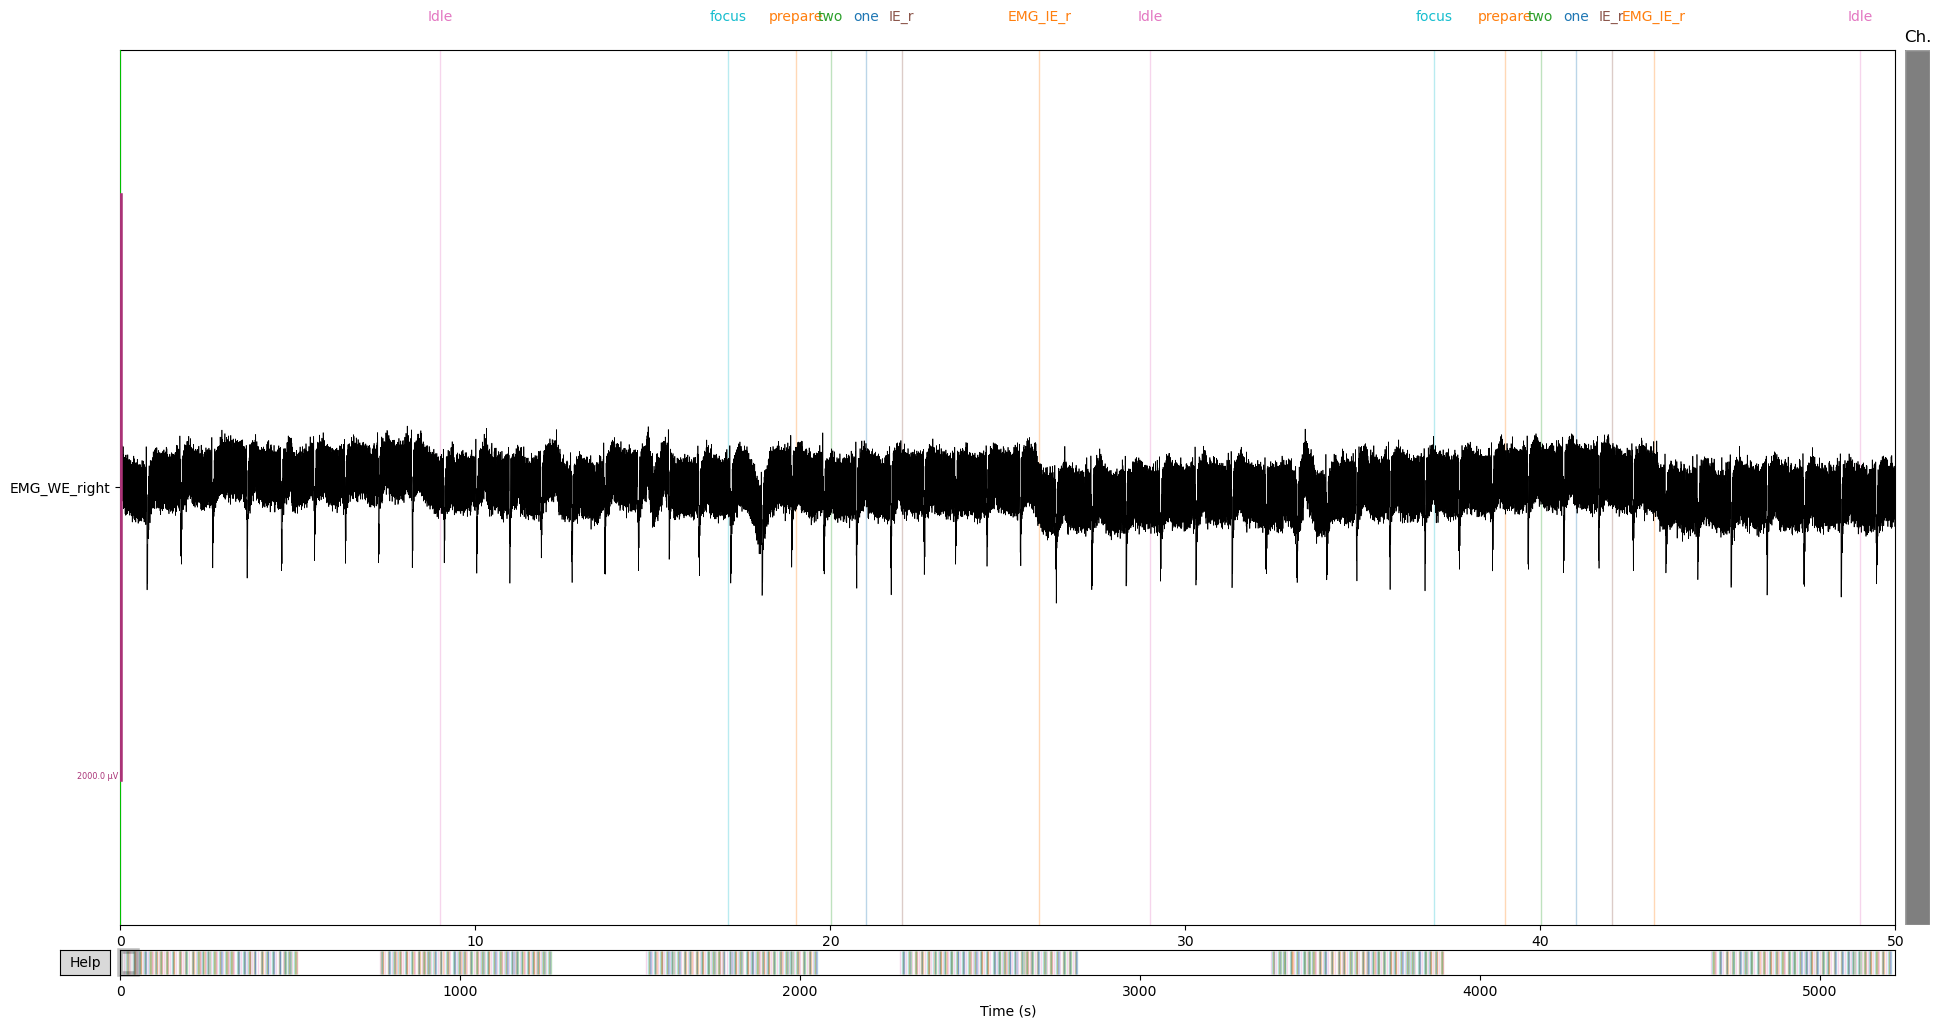

In [127]:
EMG_raw_array.pick_channels(['EMG_WE_right']).plot(duration= 50)